# Split into Train/Validation/Test

In [2]:
import os
import pandas as pd
from sklearn.model_selection import GroupShuffleSplit

# Load Data
DATASET_DIR = "/mnt/e/linux_projects/MIA/task6/task6_2/data"
df = pd.read_csv(os.path.join(DATASET_DIR, "captions.txt"))
df["caption"] = df["caption"].astype(str).str.strip()




# 15% Test
gss_test = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=42)
train_val_idx, test_idx = next(gss_test.split(df, groups=df["image"]))

train_val_df = df.iloc[train_val_idx]
test_df = df.iloc[test_idx].reset_index(drop=True)

# remaining 85% (Train 70% and Val 15%)
gss_val = GroupShuffleSplit(n_splits=1, test_size=0.1765, random_state=42)  # 17.65% of the 85% is 15% of the original data set
train_idx, val_idx = next(gss_val.split(train_val_df, groups=train_val_df["image"]))

train_df = train_val_df.iloc[train_idx].reset_index(drop=True)
val_df = train_val_df.iloc[val_idx].reset_index(drop=True)


# printing results
print("=== Split Summary ===")
print(f"Train Set: {len(train_df)} captions across {train_df['image'].nunique()} images")
print(f"Val Set:   {len(val_df)} captions across {val_df['image'].nunique()} images")
print(f"Test Set:  {len(test_df)} captions across {test_df['image'].nunique()} images")

# Ensure no image appears in more than one set
train_imgs = set(train_df["image"])
val_imgs = set(val_df["image"])
test_imgs = set(test_df["image"])

# assert len(train_imgs.intersection(val_imgs)) == 0, "Leakage between Train & Val!"
# assert (len(train_imgs.intersection(test_imgs)) == 0), "Leakage between Train & Test!"
# assert len(val_imgs.intersection(test_imgs)) == 0, "Leakage between Val & Test!"

# print("\n No data leakage detected across splits!")

=== Split Summary ===
Train Set: 28315 captions across 5663 images
Val Set:   6070 captions across 1214 images
Test Set:  6070 captions across 1214 images


# Caption preprocessing

In [ ]:
import collections
import re
import torch
from torch.nn.utils.rnn import pad_sequence


class Vocabulary:

    def __init__(self, freq_threshold=2):
        self.freq_threshold = freq_threshold

        # Special tokens
        self.pad_token = "<PAD>"
        self.sos_token = "<SOS>" # Start of Sentence
        self.eos_token = "<EOS>" # End of Sentence
        self.unk_token = "<UNK>" # unknown words (OOV)

        self.itos = { 0: self.pad_token,
                     1: self.sos_token,
                     2: self.eos_token,
                     3: self.unk_token}
        
        self.stoi = {v: k for k, v in self.itos.items()}

    def __len__(self):
        return len(self.itos)

    @staticmethod
    def tokenize(text):
        # Makes all text lowercase and get rid off non-alphanumeric characters
        text = text.lower()
        tokens = re.findall(r"\b\w+\b", text)
        return tokens

    def build_vocabulary(self, sentence_list):
        frequencies = collections.Counter()
        idx = len(self.itos)

        # Count frequencies
        for sentence in sentence_list:
            tokens = self.tokenize(sentence)
            frequencies.update(tokens)

        # Add words meeting threshold
        for word, count in frequencies.items():
            if count >= self.freq_threshold:
                self.stoi[word] = idx
                self.itos[idx] = word
                idx += 1

    def numericalize(self, text):
        # Converts text to numbers
        tokens = self.tokenize(text)
        numericalized = [self.stoi[self.sos_token]]

        for token in tokens:
            numericalized.append(self.stoi.get(token, self.stoi[self.unk_token]))

        numericalized.append(self.stoi[self.eos_token])
        return numericalized



# Building Vocabulary strictly on train_df

vocab = Vocabulary(freq_threshold=2)
vocab.build_vocabulary(train_df["caption"].tolist())

print(f"Vocabulary Size: {len(vocab)} unique tokens")










# -------------------------------------------------------------
sample_train_caption = train_df["caption"].iloc[0]
sample_val_caption = val_df["caption"].iloc[0]

train_numerical = vocab.numericalize(sample_train_caption)
val_numerical = vocab.numericalize(sample_val_caption)

print("\n--- Train Example ---")
print(f"Original Text:  '{sample_train_caption}'")
print(f"Numericalized:  {train_numerical}")
print(f"Decoded Back:   {[vocab.itos[i] for i in train_numerical]}")

print("\n--- Validation Example (Out-of-Vocab words become <UNK>) ---")
print(f"Original Text:  '{sample_val_caption}'")
print(f"Numericalized:  {val_numerical}")
print(f"Decoded Back:   {[vocab.itos[i] for i in val_numerical]}")

Vocabulary Size: 4431 unique tokens

--- Train Example ---
Original Text:  'A child in a pink dress is climbing up a set of stairs in an entry way .'
Numericalized:  [1, 4, 5, 6, 4, 7, 8, 9, 10, 11, 4, 12, 13, 14, 6, 15, 3, 16, 2]
Decoded Back:   ['<SOS>', 'a', 'child', 'in', 'a', 'pink', 'dress', 'is', 'climbing', 'up', 'a', 'set', 'of', 'stairs', 'in', 'an', '<UNK>', 'way', '<EOS>']

--- Validation Example (Out-of-Vocab words become <UNK>) ---
Original Text:  'A boy smiles in front of a stony wall in a city .'
Numericalized:  [1, 4, 214, 531, 6, 59, 13, 4, 3, 179, 6, 4, 208, 2]
Decoded Back:   ['<SOS>', 'a', 'boy', 'smiles', 'in', 'front', 'of', 'a', '<UNK>', 'wall', 'in', 'a', 'city', '<EOS>']


In [4]:
# add <PAD> token to make sure that all sequences will have the same length

class CaptionCollate:

    def __init__(self, pad_idx):
        self.pad_idx = pad_idx

    def __call__(self, batch):
        # batch contains tuples of (image_tensor, numericalized_caption_tensor)
        images = [item[0] for item in batch]
        captions = [item[1] for item in batch]

        images = torch.stack(images, dim=0)

        # Pad sequence along length dimension with <PAD> token ID
        padded_captions = pad_sequence(
            captions, batch_first=True, padding_value=self.pad_idx
        )

        return images, padded_captions


# Usage with PyTorch DataLoader
collate_fn = CaptionCollate(pad_idx=vocab.stoi["<PAD>"])

# Image feature extraction

In [ ]:
import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as transforms
from PIL import Image

transform = transforms.Compose([transforms.Resize((224, 224)), transforms.ToTensor(),
                                transforms.Normalize( mean=[0.485, 0.456, 0.406],  std=[0.229, 0.224, 0.225],),])


# ResNet-50 Encoder Class
class ResNetEncoder(nn.Module):

    def __init__(self, embed_size, use_attention=False):
        super(ResNetEncoder, self).__init__()
        self.use_attention = use_attention

        # Load pretrained ResNet-50
        resnet = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

        # Freeze parameter gradients so we don't backprop through ResNet
        for param in resnet.parameters():
            param.requires_grad = False

        # Remove Conv5 avgpool & fc layers (keep layers up to layer4 output)
        modules = list(resnet.children())[:-2]
        self.resnet = nn.Sequential(*modules)
        
    def forward(self, images):
        # Extract features -> Output shape: (Batch, 2048, 7, 7)
        features = self.resnet(images)
        
        # Reshape to spatial sequence format: (Batch, 49, 2048)
        features = features.permute(0, 2, 3, 1)
        features = features.view(features.size(0), -1, features.size(3))
        return features

In [ ]:
# Instantiate Encoder
EMBED_SIZE = 256
encoder = ResNetEncoder(embed_size=EMBED_SIZE, use_attention=False)
encoder.eval()  # Set to evaluation mode

# Load sample image (using a fallback synthetic tensor if image file is missing)
img_path = "./data/Images/1000268201_693b08cb0e.jpg"

try:
    raw_img = Image.open(img_path).convert("RGB")
    input_tensor = transform(raw_img).unsqueeze(0)  # Shape: (1, 3, 224, 224)
    print(f"Loaded image successfully from {img_path}")
except FileNotFoundError:
    print(f"Image not found at {img_path}. Creating a dummy RGB tensor for testing...")
    input_tensor = torch.randn(1, 3, 224, 224)

# Pass through Encoder
with torch.no_grad():
    feature_vector = encoder(input_tensor)

# Output Verification
print(f"Feature Vector Shape: {feature_vector.shape}")
print(f"Feature Vector Snippet:\n{feature_vector[:, :5]}")

Image not found at ./data/Images/1000268201_693b08cb0e.jpg. Creating a dummy RGB tensor for testing...
Feature Vector Shape: torch.Size([1, 49, 2048])
Feature Vector Snippet:
tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]])


# Attention

In [10]:
class BahdanauAttention(nn.Module):
    def __init__(self, encoder_dim, decoder_dim, attention_dim):
        super(BahdanauAttention, self).__init__()
        self.encoder_att = nn.Linear(encoder_dim, attention_dim)
        self.decoder_att = nn.Linear(decoder_dim, attention_dim)
        self.full_att = nn.Linear(attention_dim, 1)
        self.relu = nn.ReLU()
        self.softmax = nn.Softmax(dim=1)

    def forward(self, encoder_features, decoder_hidden):
        # encoder_features: (Batch, 49, 2048)
        # decoder_hidden: (Batch, decoder_dim)
        
        att1 = self.encoder_att(encoder_features)       # (Batch, 49, attention_dim)
        att2 = self.decoder_att(decoder_hidden)         # (Batch, attention_dim)
        
        # Add dimensions for broadcasting -> (Batch, 49, attention_dim)
        score = self.full_att(self.relu(att1 + att2.unsqueeze(1))) # (Batch, 49, 1)
        score = score.squeeze(2)                         # (Batch, 49)
        
        alpha = self.softmax(score)                      # (Batch, 49)
        context = (encoder_features * alpha.unsqueeze(2)).sum(dim=1) # (Batch, 2048)
        
        return context, alpha

# Encoder Decoder

In [11]:
class DecoderWithAttention(nn.Module):
    def __init__(self, embed_size, hidden_size, vocab_size, encoder_dim=2048, attention_dim=256, dropout=0.3):
        super(DecoderWithAttention, self).__init__()
        
        self.vocab_size = vocab_size
        self.attention = BahdanauAttention(encoder_dim, hidden_size, attention_dim)
        
        self.embedding = nn.Embedding(vocab_size, embed_size)
        self.dropout = nn.Dropout(dropout)
        self.decode_step = nn.LSTMCell(embed_size + encoder_dim, hidden_size)
        
        # Initial hidden state projections from mean spatial features
        self.init_h = nn.Linear(encoder_dim, hidden_size)
        self.init_c = nn.Linear(encoder_dim, hidden_size)
        
        self.fc = nn.Linear(hidden_size, vocab_size)

    def init_hidden_state(self, encoder_features):
        mean_encoder_features = encoder_features.mean(dim=1)
        h = torch.tanh(self.init_h(mean_encoder_features))
        c = torch.tanh(self.init_c(mean_encoder_features))
        return h, c

    def forward(self, encoder_features, captions):
        # captions: (Batch, max_seq_len)
        batch_size = encoder_features.size(0)
        seq_len = captions.size(1)
        
        embeddings = self.embedding(captions)  # (Batch, seq_len, embed_size)
        h, c = self.init_hidden_state(encoder_features)
        
        outputs = torch.zeros(batch_size, seq_len, self.vocab_size).to(encoder_features.device)
        
        for t in range(seq_len):
            context, _ = self.attention(encoder_features, h)
            
            # Concatenate token embedding with image context vector
            lstm_input = torch.cat([embeddings[:, t, :], context], dim=1)
            h, c = self.decode_step(lstm_input, (h, c))
            
            output = self.fc(self.dropout(h))
            outputs[:, t, :] = output
            
        return outputs

In [12]:
class EncoderDecoderAttention(nn.Module):
    def __init__(self, embed_size, hidden_size, vocab_size, attention_dim=256):
        super(EncoderDecoderAttention, self).__init__()
        self.encoder = ResNetEncoder(embed_size=embed_size)
        self.decoder = DecoderWithAttention(
            embed_size=embed_size,
            hidden_size=hidden_size,
            vocab_size=vocab_size,
            attention_dim=attention_dim
        )

    def forward(self, images, captions):
        features = self.encoder(images)
        outputs = self.decoder(features, captions)
        return outputs

# Image-Caption pairs

In [ ]:
# import os
# import torch
# from PIL import Image
from torch.utils.data import DataLoader, Dataset

# prepares image-caption pairs
class Flickr8kDataset(Dataset):

    def __init__(self, df, images_dir, vocab, transform=None):
        self.df = df
        self.images_dir = images_dir
        self.vocab = vocab
        self.transform = transform

        self.images = self.df["image"].tolist()
        self.captions = self.df["caption"].tolist()

    def __len__(self):
        return len(self.df)

    def __getitem__(self, index):
        caption = self.captions[index]
        img_id = self.images[index]
        img_path = os.path.join(self.images_dir, img_id)

        # Load & Transform Image
        image = Image.open(img_path).convert("RGB")
        if self.transform is not None:
            image = self.transform(image)

        # Numericalize Caption
        numericalized_caption = self.vocab.numericalize(caption)

        return image, torch.tensor(numericalized_caption)


# Assign each transformed image to a numericalized caption
train_dataset = Flickr8kDataset( df=train_df, images_dir=os.path.join(DATASET_DIR, "Images"), 
                                vocab=vocab, transform=transform,)

# DataLoader setup using the CaptionCollate from earlier
pad_idx = vocab.stoi["<PAD>"]
collate_fn = CaptionCollate(pad_idx=pad_idx)

train_loader = DataLoader( dataset=train_dataset, batch_size=32, 
                          shuffle=True, num_workers=2, collate_fn=collate_fn)

# Training

In [ ]:
import os
import torch
import torch.nn as nn
import torch.optim as optim


EMBED_SIZE = 256
HIDDEN_SIZE = 512
ATTENTION_DIM = 256
VOCAB_SIZE = len(vocab)
LEARNING_RATE = 3e-4
NUM_EPOCHS = 10

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = EncoderDecoderAttention(
    embed_size=EMBED_SIZE,
    hidden_size=HIDDEN_SIZE,
    vocab_size=VOCAB_SIZE,
    attention_dim=ATTENTION_DIM
).to(DEVICE)

pad_idx = vocab.stoi["<PAD>"]
criterion = nn.CrossEntropyLoss(ignore_index=pad_idx)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

images_directory = os.path.join(DATASET_DIR, "Images")

# Training Loop
for epoch in range(NUM_EPOCHS):
    model.train()  # Ensure model is in train mode at start of epoch
    total_loss = 0.0

    for idx, (images, captions) in enumerate(train_loader):
        images = images.to(DEVICE)
        captions = captions.to(DEVICE)

        # Zero the parameter gradients
        optimizer.zero_grad()

        # Forward pass
        # Pass all tokens except the last to decoder
        outputs = model(images, captions[:, :-1])

        # Targets are shifted by 1 token
        targets = captions[:, 1:].contiguous().view(-1)
        outputs = outputs.contiguous().view(-1, outputs.size(-1))

        loss = criterion(outputs, targets)

        # Backward pass & optimize
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        if (idx + 1) % 100 == 0:
            print(
                f"Epoch [{epoch+1}/{NUM_EPOCHS}], Step [{idx+1}/{len(train_loader)}], Step Loss: {loss.item():.4f}"
            )

    # Calculate average loss after FULL epoch completes
    avg_loss = total_loss / len(train_loader)
    print(f"\n==> Epoch [{epoch+1}/{NUM_EPOCHS}] Average Loss: {avg_loss:.4f}")

Epoch [1/10], Step [100/885], Step Loss: 4.9971
Epoch [1/10], Step [200/885], Step Loss: 4.5072
Epoch [1/10], Step [300/885], Step Loss: 4.0898
Epoch [1/10], Step [400/885], Step Loss: 3.8789
Epoch [1/10], Step [500/885], Step Loss: 3.8746
Epoch [1/10], Step [600/885], Step Loss: 3.6460
Epoch [1/10], Step [700/885], Step Loss: 3.8263
Epoch [1/10], Step [800/885], Step Loss: 3.6075

==> Epoch [1/10] Average Loss: 4.1303
Epoch [2/10], Step [100/885], Step Loss: 3.5927
Epoch [2/10], Step [200/885], Step Loss: 3.2227
Epoch [2/10], Step [300/885], Step Loss: 3.5831
Epoch [2/10], Step [400/885], Step Loss: 3.4776
Epoch [2/10], Step [500/885], Step Loss: 2.9697
Epoch [2/10], Step [600/885], Step Loss: 3.2261
Epoch [2/10], Step [700/885], Step Loss: 3.3201
Epoch [2/10], Step [800/885], Step Loss: 3.2313

==> Epoch [2/10] Average Loss: 3.2728
Epoch [3/10], Step [100/885], Step Loss: 2.8759
Epoch [3/10], Step [200/885], Step Loss: 3.0339
Epoch [3/10], Step [300/885], Step Loss: 2.7946
Epoch [3/1

In [21]:
# Define save path
SAVE_PATH = "/mnt/e/linux_projects/MIA/task6/task6_2/weights/attention_enc_dec1.pth"

# Save state dictionary
torch.save(model.state_dict(), SAVE_PATH)
print(f"Model weights saved successfully to {SAVE_PATH}")

Model weights saved successfully to /mnt/e/linux_projects/MIA/task6/task6_2/weights/attention_enc_dec1.pth


In [ ]:
import torch

# Loading Saved model weight
SAVE_PATH = "/mnt/e/linux_projects/MIA/task6/task6_2/weights/attention_enc_dec1.pth"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = EncoderDecoderAttention( embed_size=EMBED_SIZE, hidden_size=HIDDEN_SIZE,
                                 vocab_size=VOCAB_SIZE, attention_dim=ATTENTION_DIM).to(DEVICE)

model.load_state_dict(torch.load(SAVE_PATH, map_location=DEVICE, weights_only=True))

model.eval()
print("Attention model loaded successfully and ready for inference!")

Attention model loaded successfully and ready for inference!


# Evaluation metreic

In [ ]:
import collections
from nltk.translate.bleu_score import SmoothingFunction, corpus_bleu
import torch


def evaluate_bleu(model, val_df, vocab, images_dir, device, max_length=20):
    """Generates 1 caption per unique validation image and compares it

    against all 5 ground-truth references using corpus_bleu.
    """
    model.eval()

    # Group ground-truth references by image filename
    # Result structure: {'img1.jpg': [['a', 'dog', 'runs'], ['brown', 'dog', 'outside'], ...]}
    image_to_references = collections.defaultdict(list)
    for _, row in val_df.iterrows():
        img_id = row["image"]
        # Tokenize reference caption into a list of words
        ref_tokens = vocab.tokenize(row["caption"])
        image_to_references[img_id].append(ref_tokens)

    references_list = []
    hypotheses_list = []

    # Iterate through each UNIQUE image to generate a prediction
    unique_images = list(image_to_references.keys())

    with torch.no_grad():
        for img_id in unique_images:
            img_path = os.path.join(images_dir, img_id)

            # Load and preprocess image
            raw_img = Image.open(img_path).convert("RGB")
            img_tensor = transform(raw_img).unsqueeze(0).to(device)

            # --- Generate Caption (Greedy Search) ---
            features = model.encoder(img_tensor)
            states = None
            lstm_input = features.unsqueeze(1)

            predicted_tokens = []
            for _ in range(max_length):
                hiddens, states = model.decoder.lstm(lstm_input, states)
                output = model.decoder.linear(hiddens.squeeze(1))
                predicted_id = output.argmax(1).item()

                predicted_word = vocab.itos[predicted_id]
                if predicted_word == "<EOS>":
                    break

                predicted_tokens.append(predicted_word)
                lstm_input = model.decoder.embed(
                    torch.tensor([predicted_id]).to(device)
                ).unsqueeze(1)

            # Store the 5 references for this image and the single model prediction
            references_list.append(image_to_references[img_id])
            hypotheses_list.append(predicted_tokens)

    # Calculate Corpus BLEU scores (BLEU-1 to BLEU-4)
    # Smoothing technique prevents zero scores if 4-gram matches are sparse early in training
    smooth = SmoothingFunction().method1

    bleu1 = corpus_bleu(
        references_list,
        hypotheses_list,
        weights=(1.0, 0, 0, 0),
        smoothing_function=smooth,
    )
    bleu2 = corpus_bleu(
        references_list,
        hypotheses_list,
        weights=(0.5, 0.5, 0, 0),
        smoothing_function=smooth,
    )
    bleu3 = corpus_bleu(
        references_list,
        hypotheses_list,
        weights=(0.33, 0.33, 0.33, 0),
        smoothing_function=smooth,
    )
    bleu4 = corpus_bleu(
        references_list,
        hypotheses_list,
        weights=(0.25, 0.25, 0.25, 0.25),
        smoothing_function=smooth,
    )

    scores = {
        "BLEU-1": bleu1 * 100,
        "BLEU-2": bleu2 * 100,
        "BLEU-3": bleu3 * 100,
        "BLEU-4": bleu4 * 100,
    }

    print("\n=== Validation BLEU Scores ===")
    for metric, score in scores.items():
        print(f"{metric}: {score:.2f}")

    return scores

# validation

In [ ]:
import collections
import os
import torch
from nltk.translate.bleu_score import SmoothingFunction, corpus_bleu
from PIL import Image

def generate_caption_attention(model, image_path, transform, vocab, device, max_length=20):
    model.eval()
    raw_img = Image.open(image_path).convert("RGB")
    img_tensor = transform(raw_img).unsqueeze(0).to(device)

    predicted_tokens = []
    
    with torch.no_grad():
        encoder_features = model.encoder(img_tensor)
        h, c = model.decoder.init_hidden_state(encoder_features)
        
        # Start token <SOS>
        word_id = vocab.stoi["<SOS>"]
        
        for _ in range(max_length):
            context, _ = model.decoder.attention(encoder_features, h)
            embed = model.decoder.embedding(torch.tensor([word_id]).to(device))
            
            lstm_input = torch.cat([embed, context], dim=1)
            h, c = model.decoder.decode_step(lstm_input, (h, c))
            
            output = model.decoder.fc(h)
            word_id = output.argmax(1).item()
            
            predicted_word = vocab.itos[word_id]
            if predicted_word == "<EOS>":
                break
                
            predicted_tokens.append(predicted_word)
            
    return " ".join(predicted_tokens)


def evaluate_bleu_corpus(
    model, val_df, vocab, transform, images_dir, device, max_length=20
):
    """Evaluates BLEU 1-4 scores across unique validation images against ground-truth references."""
    model.eval()

    # Group ground-truth references by image filename
    image_to_references = collections.defaultdict(list)
    for _, row in val_df.iterrows():
        img_id = row["image"]
        ref_tokens = vocab.tokenize(row["caption"])
        image_to_references[img_id].append(ref_tokens)

    references_list = []
    hypotheses_list = []

    unique_images = list(image_to_references.keys())

    for img_id in unique_images:
        img_path = os.path.join(images_dir, img_id)

        # Generate text tokens using the single image function logic
        caption_str = generate_caption_attention( model, img_path, transform, vocab, device, max_length)
        print(caption_str)
        predicted_tokens = caption_str.split()

        references_list.append(image_to_references[img_id])
        hypotheses_list.append(predicted_tokens)

    # Compute BLEU Scores
    smooth = SmoothingFunction().method1
    scores = {
        "BLEU-1": corpus_bleu(
            references_list,
            hypotheses_list,
            weights=(1.0, 0, 0, 0),
            smoothing_function=smooth,
        )
        * 100,
        "BLEU-2": corpus_bleu(
            references_list,
            hypotheses_list,
            weights=(0.5, 0.5, 0, 0),
            smoothing_function=smooth,
        )
        * 100,
        "BLEU-3": corpus_bleu(
            references_list,
            hypotheses_list,
            weights=(0.33, 0.33, 0.33, 0),
            smoothing_function=smooth,
        )
        * 100,
        "BLEU-4": corpus_bleu(
            references_list,
            hypotheses_list,
            weights=(0.25, 0.25, 0.25, 0.25),
            smoothing_function=smooth,
        )
        * 100,
    }

    return scores

In [ ]:
# Create a PyTorch DataLoader for the validation set (Vector Validation)
val_dataset = Flickr8kDataset(
    df=val_df,
    images_dir=images_directory,
    vocab=vocab,
    transform=transform,
)
val_loader = DataLoader(
    dataset=val_dataset,
    batch_size=32,
    shuffle=False,
    collate_fn=collate_fn,
)


print("\nCalculating Final Validation BLEU Scores...")
bleu_scores = evaluate_bleu_corpus(
    model, val_df, vocab, transform, images_directory, DEVICE
)

for metric, score in bleu_scores.items():
    print(f"{metric}: {score:.2f}")




Calculating Final Validation BLEU Scores...
a young boy in a blue shirt and a blue jacket standing on a stone wall
a white dog is chasing a ball
a black dog is running through the water
a child in a red jacket is riding a red sled in the snow
a snowboarder is running through the snow
a girl is jumping into the air on the beach
a woman is jumping into the pool while a woman watches
a man in a blue jacket is driving a car on a street
a person in a red helmet rides a bike on a dirt bike
a woman in a blue jacket is riding a brown horse
a dog is standing on a leash next to a brown dog
a rock climber is climbing a rock face
a small dog is jumping up a large ball
a man is driving a atv through a field
a dog jumps to catch a ball in the air
a man in a green shirt is climbing a rocky cliff
a white dog is jumping in the air
a small tan dog runs through the grass
a dog with a stick in its mouth is running in a field
a young boy in a blue shirt and blue shorts is jumping in the sand
a young girl 

# test

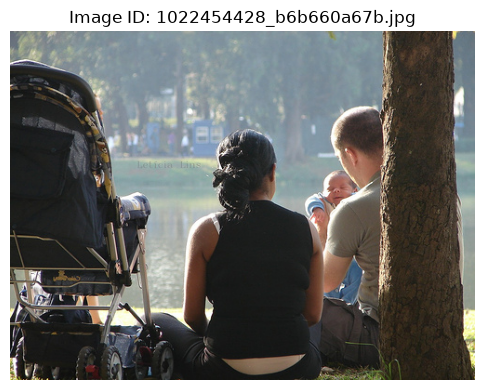

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import torch

def visualize_and_predict(df_test, index, model, vocab, transform, device, img_dir="/mnt/e/linux_projects/MIA/task6/task6_2/data/Images"):
    """
    Displays an image from the test dataframe, prints its ground truth captions,
    and prints the model's generated caption.
    """
    # Retrieve image name and ground truth captions from DataFrame
    row = df_test.iloc[index]
    img_name = row['image']
    
    # Handles both single string captions or lists of ground truth captions
    ground_truths = row['caption'] if isinstance(row['caption'], list) else [row['caption']]
    
    # Load image
    img_path = f"{img_dir}/{img_name}"
    raw_img = Image.open(img_path).convert("RGB")
    
    # Plot the image
    plt.figure(figsize=(6, 6))
    plt.imshow(raw_img)
    plt.axis("off")
    plt.title(f"Image ID: {img_name}")
    plt.show()
    
    # Generate prediction using the model
    model.eval()
    img_tensor = transform(raw_img).unsqueeze(0).to(device)
    
    predicted_tokens = []
    with torch.no_grad():
        encoder_features = model.encoder(img_tensor)
        h, c = model.decoder.init_hidden_state(encoder_features)
        
        word_id = vocab.stoi["<SOS>"]
        for _ in range(20):  # max_length
            context, _ = model.decoder.attention(encoder_features, h)
            embed = model.decoder.embedding(torch.tensor([word_id]).to(device))
            
            lstm_input = torch.cat([embed, context], dim=1)
            h, c = model.decoder.decode_step(lstm_input, (h, c))
            
            output = model.decoder.fc(h)
            word_id = output.argmax(1).item()
            
            predicted_word = vocab.itos[word_id]
            if predicted_word == "<EOS>":
                break
            predicted_tokens.append(predicted_word)
            
    generated_caption = " ".join(predicted_tokens)


# Usage Example:
visualize_and_predict(test_df, index=0, model=model, vocab=vocab, transform=transform, device=DEVICE)

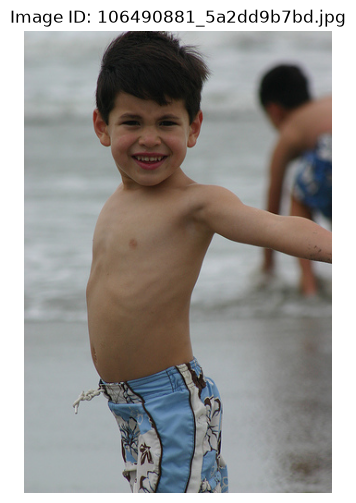

=== Results for Sample #41 (106490881_5a2dd9b7bd.jpg) ===
Ground Truth Caption(s):
  1. A boy smiles for the camera at a beach .

Generated Caption:
  -> a young boy wearing a blue shirt is standing on a beach


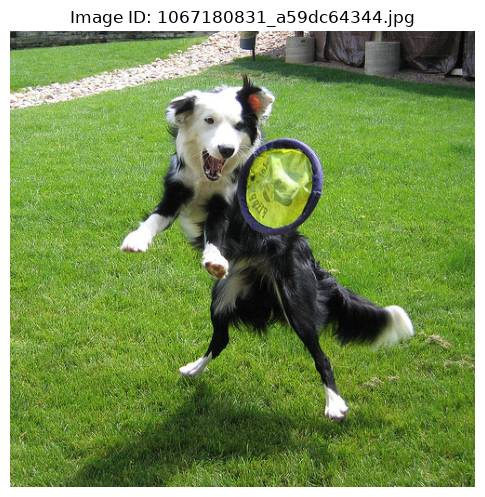

=== Results for Sample #46 (1067180831_a59dc64344.jpg) ===
Ground Truth Caption(s):
  1. A black and white dog jumps after a yellow toy .

Generated Caption:
  -> a black and white dog is running on the grass


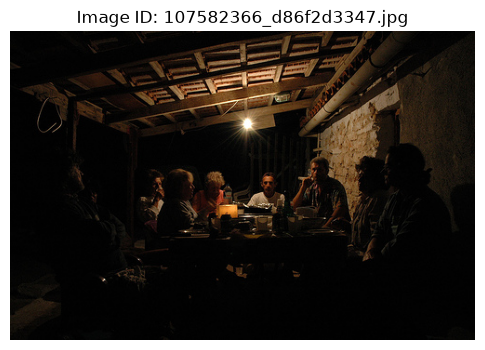

=== Results for Sample #51 (107582366_d86f2d3347.jpg) ===
Ground Truth Caption(s):
  1. A group of people gathered around in the dark .

Generated Caption:
  -> a group of people are sitting at a table in a dimly lit lit restaurant


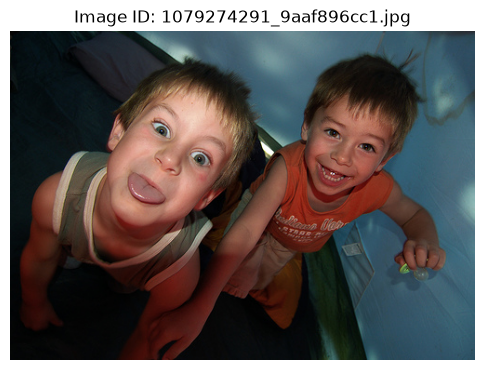

=== Results for Sample #56 (1079274291_9aaf896cc1.jpg) ===
Ground Truth Caption(s):
  1. Two boys make faces .

Generated Caption:
  -> a young boy is smiling at the camera


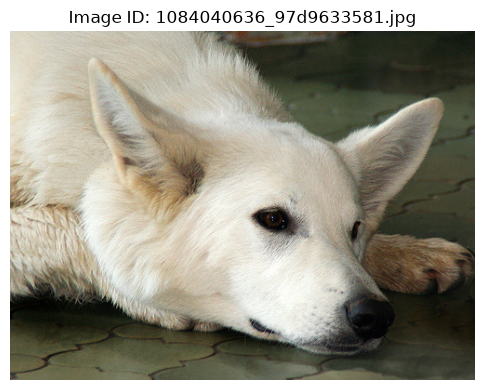

=== Results for Sample #61 (1084040636_97d9633581.jpg) ===
Ground Truth Caption(s):
  1. a large white dog lying on the floor .

Generated Caption:
  -> a white dog is walking along the side of a white dog


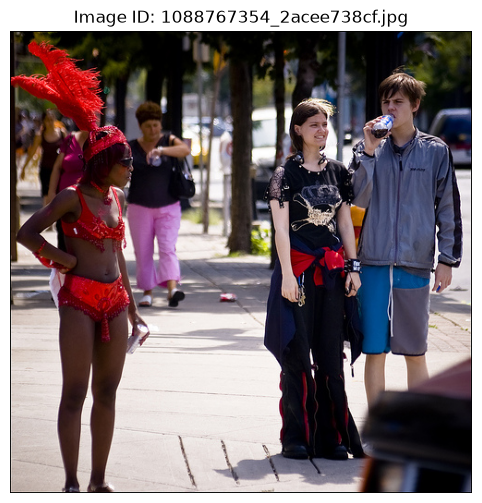

=== Results for Sample #66 (1088767354_2acee738cf.jpg) ===
Ground Truth Caption(s):
  1. A woman wearing a red costume looks at two other people standing on a street .

Generated Caption:
  -> a girl in a red skirt and red shorts is holding a cup


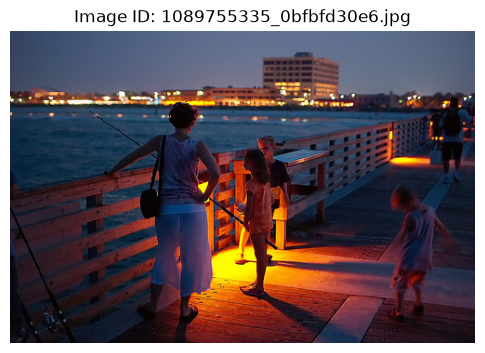

=== Results for Sample #71 (1089755335_0bfbfd30e6.jpg) ===
Ground Truth Caption(s):
  1. A woman and three children stand on a deck with a fishing pole .

Generated Caption:
  -> a man and a woman are walking on a bridge near a city


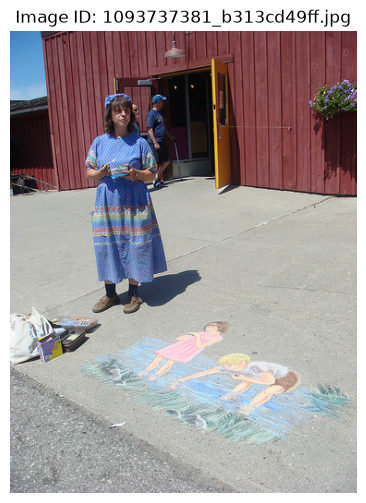

=== Results for Sample #76 (1093737381_b313cd49ff.jpg) ===
Ground Truth Caption(s):
  1. A woman standing in front of a chalk drawing

Generated Caption:
  -> a boy is doing a skateboard trick in the air


In [52]:
# Usage Example:
for i in range(1 + 40,41 + 40,5):
    visualize_and_predict(test_df, index=i, model=model, vocab=vocab, transform=transform, device=DEVICE)    